# Notebook 01 — Autoencoder

**Generative AI learning series:** Notebook 01 → Autoencoder · Notebook 02 → VAE · Notebook 03 → GAN

## 01. Introduction — What Is an Autoencoder?

> **How can a neural network learn a compact representation of an image without being explicitly told what the representation should be?**

**Concept.** An Autoencoder is trained to reproduce its own input. It must pass the input through a small **bottleneck**, so it cannot simply copy every pixel; it must learn what information is useful.

**Intuition and pipeline:**

```text
Input image x → Encoder → latent vector z → Decoder → reconstructed image x̂
```

* `x` is the input image; the encoder `f_θ` compresses it.
* `z` is the compact latent representation.
* The decoder `g_φ` expands `z` back into an image, `x̂`.

**Equations:**

$$z=f_\theta(x)$$
$$\hat{x}=g_\phi(z)$$
$$\hat{x}=g_\phi(f_\theta(x))$$

The objective is simply:

$$x\approx\hat{x}$$

This notebook builds the model from scratch on FashionMNIST and then tests whether its latent space is suitable for generation. We do not introduce VAE yet.

## 02. Why Representation Learning?

**Concept.** Representation learning lets a model discover features instead of receiving hand-designed features.

For FashionMNIST, the contrast is:

```text
Original image:        784 numbers (28 × 28 pixels)
Latent representation:   2 numbers (LATENT_DIM = 2)
```

**Intuition.** Reconstructing an image from only two numbers forces the network to preserve the most useful visual information. This supports dimensionality reduction, feature extraction, compact storage, and a space where nearby points may represent similar images.

No class labels are used to train the Autoencoder: the input image is its own target. Labels are used only later to color an explanatory visualization.

## 03. Encoder / Decoder Intuition

### Encoder: learns compression

```text
784 → 256 → 128 → 2
```

The encoder progressively reduces the input until the two-number bottleneck. It learns a function that maps a high-dimensional image to a compact code.

### Decoder: learns reconstruction

```text
2 → 128 → 256 → 784
```

The decoder learns to turn the code back into the original data. The two networks are trained together: the encoder learns compression and the decoder learns reconstruction. The bottleneck is an information constraint, not a label predictor.

## Setup — Reproducibility and Device

We seed Python, NumPy, and PyTorch (including CUDA when available). The selected device is printed so the same notebook can run on CPU or GPU.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


## 04. Dataset — FashionMNIST

**Concept.** FashionMNIST contains grayscale 28×28 clothing images. `transforms.ToTensor()` converts them to tensors shaped `[1, 28, 28]` with pixel values in `[0, 1]`. We use `BATCH_SIZE = 128` and a fully connected network, so each image will be flattened to 784 values.

**Question.** What do the images look like, and how does their shape change before the model sees them?

In [2]:
BATCH_SIZE = 128
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

pin_memory = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Train examples:", len(train_dataset))
print("Test examples :", len(test_dataset))

Train examples: 60000
Test examples : 10000


In [3]:
# A single sample is a 1-channel 28×28 tensor.
image, label = train_dataset[0]
print("Single image shape:", tuple(image.shape))
print("Class:", label, CLASS_NAMES[label])
print("Pixel range:", image.min().item(), "to", image.max().item())

# A batch is [batch, 1, 28, 28]; a Linear network needs [batch, 784].
x_batch, y_batch = next(iter(train_loader))
x_flat = x_batch.view(x_batch.size(0), -1)
print("Batch before flattening:", tuple(x_batch.shape))
print("Batch after flattening :", tuple(x_flat.shape))

Single image shape: (1, 28, 28)
Class: 9 Ankle boot
Pixel range: 0.0 to 1.0
Batch before flattening: (128, 1, 28, 28)
Batch after flattening : (128, 784)


### Dataset visualization

**Question:** *What variety must the Autoencoder compress?* The class names are shown for orientation only; these labels are not training targets.

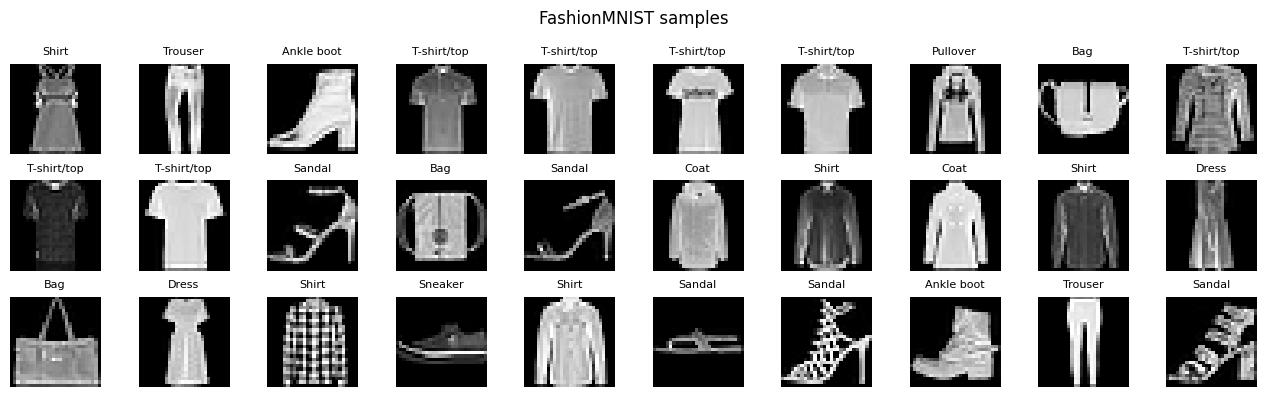

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(13, 4))
for ax in axes.flat:
    index = random.randrange(len(train_dataset))
    img, lbl = train_dataset[index]
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(CLASS_NAMES[lbl], fontsize=8)
    ax.axis("off")
plt.suptitle("FashionMNIST samples")
plt.tight_layout()
plt.show()

## 05. Build the Encoder From Scratch

**Concept → intuition → equation.** The encoder is `784 → 256 → 128 → 2`. The final 2-dimensional layer is an information bottleneck:

$$z=f_\theta(x),\qquad f_\theta:\mathbb{R}^{784}\to\mathbb{R}^{2}$$

We choose `LATENT_DIM = 2` so the complete learned representation can be plotted directly. Each `Linear` and `ReLU` is written explicitly; there is no hidden architecture.

In [5]:
LATENT_DIM = 2

class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.fc1(x))
        h = self.relu(self.fc2(h))
        z = self.fc3(h)
        return z

encoder = Encoder().to(device)
print(encoder)

Encoder(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


## 06. Build the Decoder From Scratch

**Concept → intuition → equation.** The decoder reverses the expansion: `2 → 128 → 256 → 784`.

$$\hat{x}=g_\phi(z),\qquad g_\phi:\mathbb{R}^{2}\to\mathbb{R}^{784}$$

Because `ToTensor()` puts target pixels in `[0, 1]`, the final `Sigmoid` is appropriate: every decoded pixel is also in `[0, 1]`, matching the Binary Cross Entropy requirement.

In [6]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 784)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        h = self.relu(self.fc1(z))
        h = self.relu(self.fc2(h))
        x_hat = self.sigmoid(self.fc3(h))
        return x_hat

decoder = Decoder().to(device)
print(decoder)

Decoder(
  (fc1): Linear(in_features=2, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


## 07. Build the Complete Autoencoder

**Concept.** Join the two halves into the complete architecture:

```text
784 → 256 → 128 → 2 → 128 → 256 → 784
```

The model exposes `encode()`, `decode()`, and `forward()`. The forward pass returns both `x_hat` and `z`, because later experiments need the latent code.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

model = Autoencoder().to(device)
print(model)

# Shape check on a real batch.
with torch.no_grad():
    x_hat_check, z_check = model(x_flat.to(device))
print("Input :", tuple(x_flat.shape))
print("Latent:", tuple(z_check.shape))
print("Output:", tuple(x_hat_check.shape))

Autoencoder(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (fc3): Linear(in_features=128, out_features=2, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=256, bias=True)
    (fc3): Linear(in_features=256, out_features=784, bias=True)
    (relu): ReLU()
    (sigmoid): Sigmoid()
  )
)
Input : (128, 784)
Latent: (128, 2)
Output: (128, 784)


## 08. Reconstruction Loss

**Concept.** The network is not asked to predict a class. Its target is the original image, so it minimizes the difference between `x` and `x_hat`.

**Equation:**

$$L_{reconstruction}=\operatorname{BCE}(x,\hat{x})$$

We use `F.binary_cross_entropy` because both the target pixels and sigmoid outputs are in `[0, 1]`. This measures pixel-wise reconstruction error. The model learns from images alone; class labels do not enter this loss.

In [8]:
# A small numerical example of the exact loss used during training.
example_target = x_flat.to(device)
example_output = model(example_target)[0]
example_loss = F.binary_cross_entropy(example_output, example_target)
print("Example reconstruction loss:", example_loss.item())

Example reconstruction loss: 0.692976713180542


## 09. Training Loop From Scratch

**Concept → equation → code.** We use Adam with the fixed teaching settings `EPOCHS = 20` and `LR = 1e-3`. Every iteration visibly performs: flatten, move to device, `model.train()`, `zero_grad()`, forward, BCE, backward, and `step()`.

The loss is averaged over the number of images, not hardcoded to a particular final batch length.

In [9]:
EPOCHS = 20
LR = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LR)
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    seen_images = 0

    for images, _ in train_loader:
        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()
        x_hat, z = model(images)
        loss = F.binary_cross_entropy(x_hat, images)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        seen_images += batch_size

    epoch_loss = running_loss / seen_images
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Loss: {epoch_loss:.6f}")

Epoch 01/20 | Loss: 0.364375
Epoch 02/20 | Loss: 0.331193
Epoch 03/20 | Loss: 0.326866
Epoch 04/20 | Loss: 0.324828
Epoch 05/20 | Loss: 0.323333
Epoch 06/20 | Loss: 0.322195
Epoch 07/20 | Loss: 0.321246
Epoch 08/20 | Loss: 0.320665
Epoch 09/20 | Loss: 0.319827
Epoch 10/20 | Loss: 0.319149
Epoch 11/20 | Loss: 0.318946
Epoch 12/20 | Loss: 0.318657
Epoch 13/20 | Loss: 0.317847
Epoch 14/20 | Loss: 0.317405
Epoch 15/20 | Loss: 0.317340
Epoch 16/20 | Loss: 0.316814
Epoch 17/20 | Loss: 0.317052
Epoch 18/20 | Loss: 0.316481
Epoch 19/20 | Loss: 0.316229
Epoch 20/20 | Loss: 0.316147


### Training-loss visualization

**Question:** *Did reconstruction improve as the model learned?* A decreasing BCE curve means the model is becoming better at rebuilding its inputs. It does not by itself mean that the latent space is a good generator.

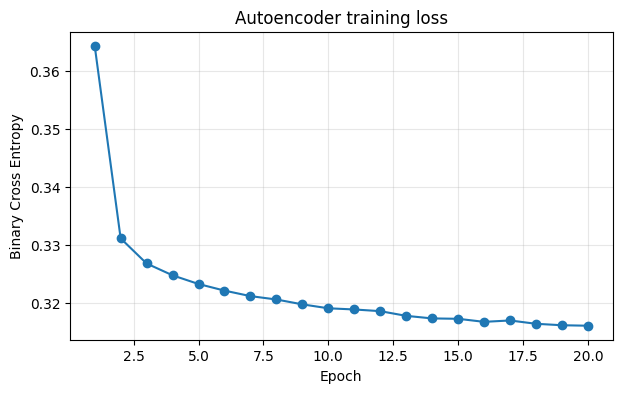

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy")
plt.title("Autoencoder training loss")
plt.grid(alpha=0.3)
plt.show()

## 10. Reconstruction Visualization

**Question:** *What information survived the 2-number bottleneck?*

After training, we evaluate with `model.eval()` and `torch.no_grad()`. The original and reconstructed images are paired so we can inspect preserved shapes and lost details. Some blur or missing detail is expected: the model had to compress 784 values into 2.

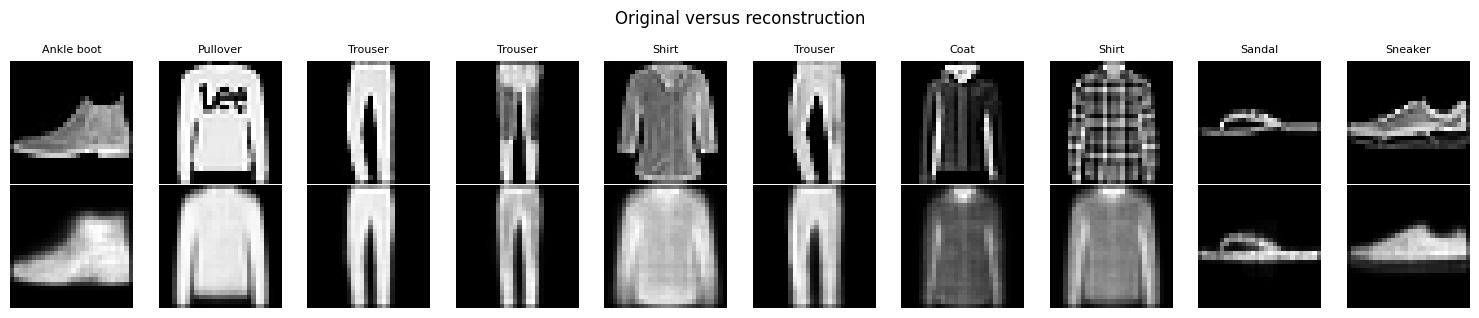

In [11]:
model.eval()
with torch.no_grad():
    test_images, test_labels = next(iter(test_loader))
    test_flat = test_images.view(test_images.size(0), -1).to(device)
    reconstructed, test_z = model(test_flat)
    reconstructed = reconstructed.cpu().view(-1, 1, 28, 28)

n_show = min(10, test_images.size(0))
fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3.2))
for i in range(n_show):
    axes[0, i].imshow(test_images[i].squeeze(0), cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[test_labels[i].item()], fontsize=8)
    axes[1, i].imshow(reconstructed[i].squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstruction")
plt.suptitle("Original versus reconstruction")
plt.tight_layout()
plt.show()

## 11. Visualize the 2D Latent Space

**Question:** *Does the learned representation organize clothing images in a meaningful way?*

We encode every test image and plot `z[:, 0]` against `z[:, 1]`, coloring points by class. The labels are **not** used for training — they only help us interpret the representation afterward.

We may see clusters, overlap, or nearby semantic structure. We must not claim perfect class separation: reconstruction pressure is different from classification pressure.

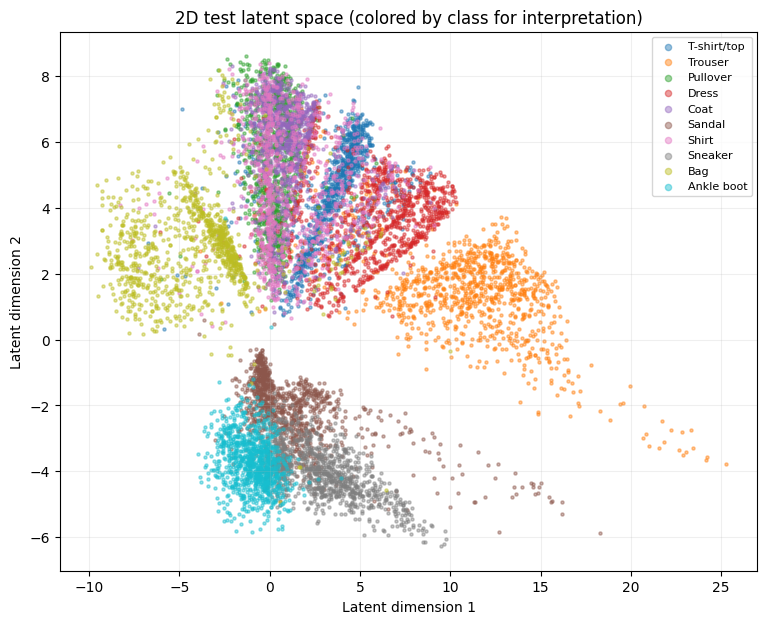

In [12]:
# Encode the complete test set without storing gradients.
all_latents = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        flat_images = images.view(images.size(0), -1).to(device)
        _, latents = model(flat_images)
        all_latents.append(latents.cpu())
        all_labels.append(labels)

all_latents = torch.cat(all_latents, dim=0)
all_labels = torch.cat(all_labels, dim=0)

plt.figure(figsize=(9, 7))
for class_id, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == class_id
    plt.scatter(all_latents[mask, 0], all_latents[mask, 1], s=5, alpha=0.45, label=class_name)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D test latent space (colored by class for interpretation)")
plt.legend(markerscale=2, fontsize=8)
plt.grid(alpha=0.2)
plt.show()

## 12. Latent Space Exploration

**Question:** *What image does a real latent point decode to?*

We select several latent vectors that actually came from real test images and decode them. This is different from inventing arbitrary points: these vectors are known to be visited by the encoder on data.

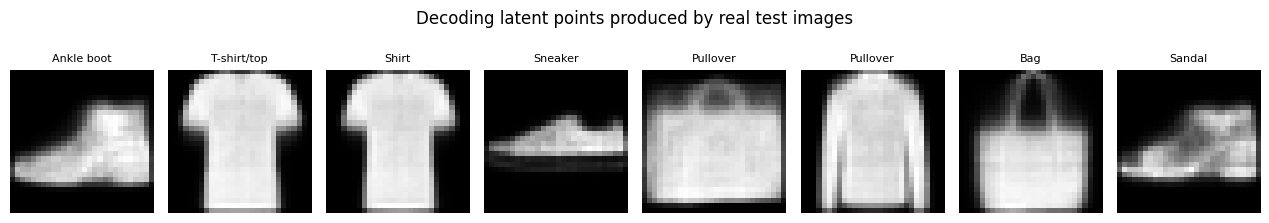

These latent points came from real images; the standard AE does not force all other points to be useful.


In [13]:
n_points = min(8, all_latents.size(0))
selected_indices = torch.linspace(0, all_latents.size(0) - 1, steps=n_points).long()
selected_z = all_latents[selected_indices].to(device)
selected_labels = all_labels[selected_indices]

model.eval()
with torch.no_grad():
    decoded_real_points = model.decode(selected_z).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(1, n_points, figsize=(1.6 * n_points, 2.4))
if n_points == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(decoded_real_points[i].squeeze(0), cmap="gray")
    ax.set_title(CLASS_NAMES[selected_labels[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Decoding latent points produced by real test images")
plt.tight_layout()
plt.show()

print("These latent points came from real images; the standard AE does not force all other points to be useful.")

## 13. Latent Interpolation

**Question:** *Does the decoder change smoothly between two real examples?*

Choose two encoded test images and linearly interpolate:

$$z(t)=(1-t)z_1+t z_2,\qquad t\in[0,1]$$

We use approximately 10 steps. Smooth or meaningful changes are possible, but not guaranteed: the geometry was learned indirectly through reconstruction, not imposed by a probabilistic prior.

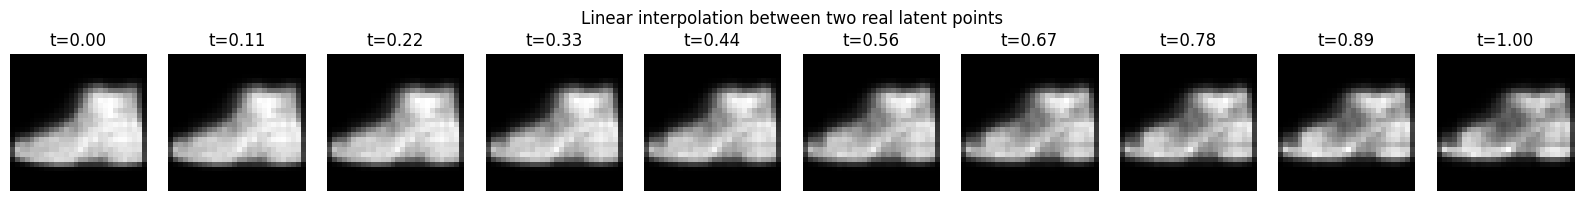

In [14]:
# Two real latent endpoints and approximately ten equally spaced steps.
first_index = 0
last_index = all_latents.size(0) - 1
z1 = all_latents[first_index].to(device)
z2 = all_latents[last_index].to(device)
interpolation_steps = 10
t_values = torch.linspace(0.0, 1.0, interpolation_steps, device=device)
interpolated_z = torch.stack([(1.0 - t) * z1 + t * z2 for t in t_values])

model.eval()
with torch.no_grad():
    interpolation_images = model.decode(interpolated_z).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(1, interpolation_steps, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(interpolation_images[i].squeeze(0), cmap="gray")
    ax.set_title(f"t={t_values[i].item():.2f}")
    ax.axis("off")
plt.suptitle("Linear interpolation between two real latent points")
plt.tight_layout()
plt.show()

## 14. Critical Experiment — Can We Generate Random Images?

**Question:** *What happens if we ignore the encoder and sample a random latent vector?*

We sample exactly as a naive generator might:

```python
z = torch.randn(64, LATENT_DIM)
generated = decoder(z)
```

We do not filter, tune, or artificially improve the outputs. They may be noisy, strange, unrealistic, or occasionally FashionMNIST-like. That honest result exposes the limitation of the standard Autoencoder.

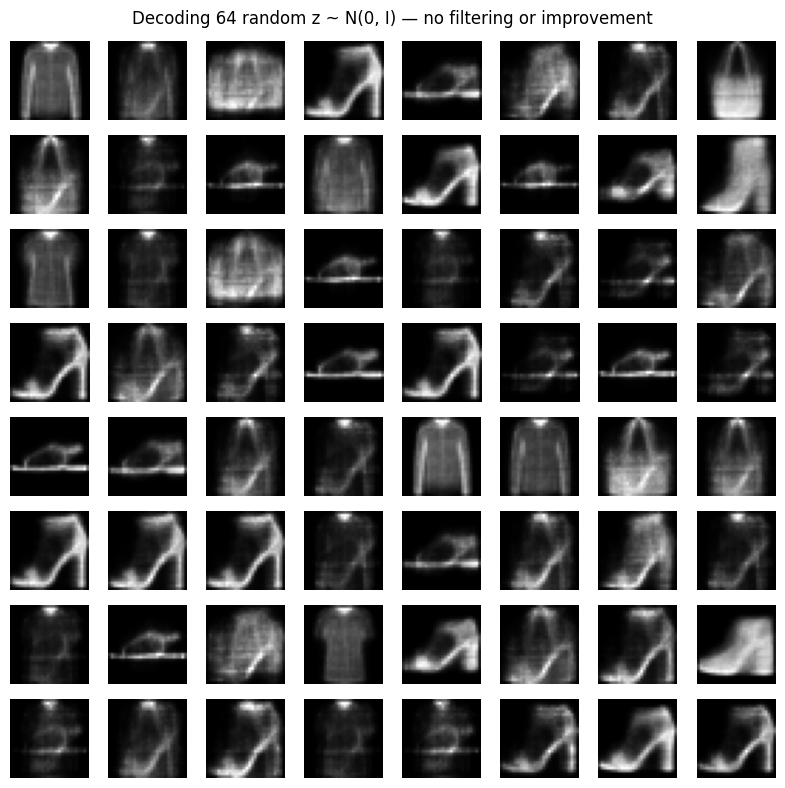

In [15]:
random_z = torch.randn(64, LATENT_DIM, device=device)
model.eval()
with torch.no_grad():
    random_generated = model.decode(random_z).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(random_generated[i].squeeze(0), cmap="gray")
    ax.axis("off")
plt.suptitle("Decoding 64 random z ~ N(0, I) — no filtering or improvement")
plt.tight_layout()
plt.show()

## 15. Why a Standard Autoencoder Is Not Automatically a Good Generator

A standard Autoencoder sees this during training:

```text
real images → encoder → latent points actually visited → decoder → reconstructions
```

But random generation asks for this:

```text
random z → decoder → image
```

The encoder learns `z=f_θ(x)` for the training distribution, but it does **not** explicitly constrain the latent codes to follow a known prior such as a standard normal distribution. Therefore, an arbitrary random `z` may land outside the useful regions visited by real data.

```text
                 LATENT SPACE

        ● ● ●
      ● ● ● ●       useful region: encoded real images
    ● ● ●

                         ○  random z may be elsewhere
```

This is the central distinction:

* reconstruction asks whether `x → encoder → z → decoder` works for data;
* generation asks whether a chosen distribution of `z` reliably lands in useful regions.

The standard AE solves the first problem, not necessarily the second.

## 16. Transition — From AE to VAE

**Problem discovered:** the Autoencoder's latent space has no explicit probabilistic structure.

A standard AE is deterministic:

```text
x → Encoder → z → Decoder
```

The conceptual VAE transition is:

```text
x → Encoder → μ, log σ² → sample z → Decoder
```

A VAE introduces a prior, a probabilistic encoder, sampling, and KL divergence. The KL term regularizes the latent distribution so that sampling from a known prior becomes meaningful.

We will not teach the full VAE here. The bridge is:

> **Notebook 02 will replace the deterministic latent point with a structured probability distribution.**

## 17. Final Summary

### Autoencoder

$$z=f_\theta(x)$$
$$\hat{x}=g_\phi(z)$$

### Main objective

$$L=L_{reconstruction}$$

### Main pipeline

```text
x → Encoder → z → Decoder → x̂
```

### What we learned

* An Autoencoder learns a compressed representation without labels.
* The encoder maps high-dimensional input into a smaller latent space.
* The decoder reconstructs the original data.
* With `LATENT_DIM = 2`, the representation is directly visualizable.
* Interpolation lets us explore learned latent geometry.
* Random latent sampling is not guaranteed to produce meaningful images.
* A standard AE does not organize its latent space around a known distribution.
* This limitation motivates the Variational Autoencoder.

```text
Notebook 01 — Autoencoder
            ↓
Problem discovered:
"How can we make latent space structured
enough for reliable generation?"
            ↓
Notebook 02 — Variational Autoencoder
```

**Closing bridge:** In Notebook 02, we will replace the deterministic latent point with a structured probability distribution.